In [ ]:
# @title Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Intro to Gemini Embedding 2

<table align="left">
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/GoogleCloudPlatform/generative-ai/blob/main/gemini/embedding/intro_gemini_embedding.ipynb">
      <img width="32px" src="https://www.gstatic.com/pantheon/images/bigquery/welcome_page/colab-logo.svg" alt="Google Colaboratory logo"><br> Open in Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https:%2F%2Fraw.githubusercontent.com%2FGoogleCloudPlatform%2Fgenerative-ai%2Fmain%2Fgemini%2Fembedding%2Fintro_gemini_embedding.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Google Cloud Colab Enterprise logo"><br> Open in Colab Enterprise
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/workbench/deploy-notebook?download_url=https://raw.githubusercontent.com/GoogleCloudPlatform/generative-ai/main/gemini/embedding/intro_gemini_embedding.ipynb">
      <img src="https://www.gstatic.com/images/branding/gcpiconscolors/vertexai/v1/32px.svg" alt="Vertex AI logo"><br> Open in Vertex AI Workbench
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/embedding/intro_gemini_embedding.ipynb">
      <img width="32px" src="https://raw.githubusercontent.com/primer/octicons/refs/heads/main/icons/mark-github-24.svg" alt="GitHub logo"><br> View on GitHub
    </a>
  </td>
</table>

<div style="clear: both;"></div>

<p>
<b>Share to:</b>

<a href="https://www.linkedin.com/sharing/share-offsite/?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/embedding/intro_gemini_embedding.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/8/81/LinkedIn_icon.svg" alt="LinkedIn logo">
</a>

<a href="https://bsky.app/intent/compose?text=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/embedding/intro_gemini_embedding.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/7/7a/Bluesky_Logo.svg" alt="Bluesky logo">
</a>

<a href="https://twitter.com/intent/tweet?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/embedding/intro_gemini_embedding.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/5/5a/X_icon_2.svg" alt="X logo">
</a>

<a href="https://reddit.com/submit?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/embedding/intro_gemini_embedding.ipynb" target="_blank">
  <img width="20px" src="https://redditinc.com/hubfs/Reddit%20Inc/Brand/Reddit_Logo.png" alt="Reddit logo">
</a>

<a href="https://www.facebook.com/sharer/sharer.php?u=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/embedding/intro_gemini_embedding.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/5/51/Facebook_f_logo_%282019%29.svg" alt="Facebook logo">
</a>
</p>

| Authors |
| --- |
| [Tengxin Li](https://github.com/tengxin-li) |
| [Eric Dong](www.linkedin.com/in/edong186) |

## Overview

**Gemini Embedding 2** is Google's multimodal embedding model for high-performance embedding generation, specifically designed to power complex retrieval and advanced analytics.

The model processes a wide array of input modalities including **text, images, documents, audio, and video** to generate dense, 3072-dimensional vectors. These embeddings are positioned within a unified semantic space, ensuring that disparate data types with similar conceptual meanings are represented by mathematically proximal vectors.

Learn more about [Gemini Embedding 2](https://docs.cloud.google.com/vertex-ai/generative-ai/docs/models/gemini/embedding-2).

This notebook demonstrates how to implement Gemini Embedding 2 for generating high-dimensional vector representations.

## Getting Started

### Install Google Gen AI SDK for Python

In [67]:
%pip install --upgrade --quiet google-genai pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 47.1 MB/s eta 0:00:00


### Import libraries


In [69]:
import io
import os
import sys

import fitz
from google import genai
from google.genai import types

### Authenticate your notebook environment

If you are running this notebook on Google Colab, run the cell below to authenticate your environment.

In [27]:
if "google.colab" in sys.modules:
    from google.colab import auth

    auth.authenticate_user()

### Autenticate your Google Cloud Project for Vertex AI

You can use a Google Cloud Project or an API Key for authentication. This tutorial uses a Google Cloud Project.

- [Enable the Vertex AI API](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com)

In [46]:
# fmt: off
# TODO: replace with template
PROJECT_ID = "[your-project-id]"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}
# fmt: on
if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

LOCATION = "us-central1"

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

### Choose a Gemini Embedding model

Use `gemini-embedding-2-preview` in this tutorial.

In [47]:
# fmt: off
MODEL_ID = "gemini-embedding-2-preview"  # @param ["gemini-embedding-2-preview"] {type: "string"}
# fmt: on

## Generate Text Embeddings

Call the `embed_content` method with the model to generate text embeddings. You can embed a list of multiple prompts with one API call for efficiency.


In [48]:
response = client.models.embed_content(
    model=MODEL_ID,
    contents=[
        "How do I get a driver's license/learner's permit?",
        "How do I renew my driver's license?",
        "How do I change my address on my driver's license?",
    ],
)

print(response.embeddings)

[ContentEmbedding(
  statistics=ContentEmbeddingStatistics(
    token_count=38.0
  ),
  values=[
    -0.00074059726,
    -0.01894553,
    0.004571431,
    0.008232674,
    0.0037022897,
    <... 3067 more items ...>,
  ]
)]


### Set embeddings dimensionality

The model is able to compress information into the earlier dimensions of the vector so it supports lower embedding dimensions. Specify `output_dimensionality` to truncate the output.

- Default: 3072 dimensions.
- Reduced Dimensions: You can specify a lower value to significantly reduce storage costs and increase search speed with minimal loss in accuracy.


In [32]:
text = ["Hello world"]
# Not truncated
result1 = client.models.embed_content(model=MODEL_ID, contents=text)


# Truncated
result2 = client.models.embed_content(
    model=MODEL_ID,
    contents=text,
    config=types.EmbedContentConfig(output_dimensionality=10),
)

[embedding1] = result1.embeddings
[embedding2] = result2.embeddings


(len(embedding1.values), len(embedding2.values))

(3072, 10)

## Geneate Multimodal embeddings

The model supports the following formats:

- Text	Supports up to 8,192 tokens.
- Image	Maximum of 6 images per request. Supported formats: PNG, JPEG.
- PDF	Maximum of 6 pages.
- Audio	Maximum duration of 80 seconds. Supported formats: MP3, WAV.
- Video	Maximum duration of 128 seconds. Supported formats: MP4, MOV.

The overall maximum input tokens limit is 8192 tokens.

### Embed images

The following example shows how to embed an image.

In [76]:
!wget -O cookies.png https://storage.googleapis.com/cloud-samples-data/generative-ai/image/cookies.png -q

In [77]:
with open("cookies.png", "rb") as f:
    image_bytes = f.read()

result = client.models.embed_content(
    model=MODEL_ID,
    contents=[
        types.Part.from_bytes(
            data=image_bytes,
            mime_type="image/png",
        ),
    ],
)

print(result.embeddings)

[ContentEmbedding(
  statistics=ContentEmbeddingStatistics(
    token_count=258.0
  ),
  values=[
    0.0005335642,
    -0.0047782515,
    -0.016738001,
    -0.0074839755,
    0.016840285,
    <... 3067 more items ...>,
  ]
)]


### Embedding aggregation

When working with multimodal content, how you structure your input affects the
embedding output:

*   **Single content entry:** Submitting multiple parts (for example, text and an
    image) within a single content entry produces one aggregated embedding for
    all modalities within that entry.
*   **Multiple entries:** Sending multiple entries in the `contents` array
    returns separate embeddings for each entry.
*   **Post-level representation:** For complex objects like social media posts
    with multiple media items, we recommend aggregating separate embeddings
    (for example, by averaging) to create a coherent post-level representation.

The following example shows how to create one aggregated embedding for text and image input.
Use the `parts` field to combine multiple inputs:

In [78]:
with open("cookies.png", "rb") as f:
    image_bytes = f.read()

result = client.models.embed_content(
    model=MODEL_ID,
    contents=[
        types.Content(
            parts=[
                types.Part(text="An image of cookies"),
                types.Part.from_bytes(
                    data=image_bytes,
                    mime_type="image/png",
                ),
            ]
        )
    ],
)

# This produces one embedding
for embedding in result.embeddings:
    print(embedding.values)

[0.006468543, 0.024488028, -0.011667618, -0.021637509, 0.037019055, -0.00877166, 0.010084919, -0.023315717, 0.0027038485, -0.025211731, -0.0013879235, 0.0030015362, -0.0059417356, -0.022494007, 0.004108398, -0.0250932, 0.010847604, -0.005345884, -0.01941983, 0.005474265, -0.0032768548, -0.0053290874, 0.0025847123, 0.005406267, 0.0007611618, 0.02874488, -0.011499627, -0.0005866653, -0.013263655, 0.09551924, -0.00644352, 0.0075268657, -0.019400166, 0.0024905736, 0.01692627, 0.013167641, 0.020563206, -0.0018913192, 0.0073099523, -0.008287579, -0.0055578235, -0.006195273, -0.013435454, 0.0089588035, -0.02633804, 0.014236578, 0.008331748, -0.008411219, 0.011619902, 0.0118714925, 0.014429476, -0.0032089227, 0.012690298, 0.008657186, 0.023419678, -0.0015989812, -0.008767474, 0.0014507008, 0.008213776, 0.00012021082, 0.014666754, -0.008689533, 0.00015760878, -0.005434696, -0.008628497, -0.008715361, -0.02262504, -0.024769954, 0.013152038, -0.010535157, -0.0030254265, -0.024833389, -0.024474205

On the other hand, this example creates multiple embeddings in one embedding call:

In [79]:
result = client.models.embed_content(
    model=MODEL_ID,
    contents=[
        "the cookies are delicious",
        types.Part.from_bytes(
            data=image_bytes,
            mime_type="image/png",
        ),
    ],
)

# This produces two embeddings
for embedding in result.embeddings:
    print(embedding.values)

[0.0122010205, 0.009633369, -0.019848457, -0.005303078, 0.025133388, -0.010315599, 0.016109928, -0.032017175, 0.020474156, -0.027679425, -0.011428682, -0.0013111392, -0.012356782, -0.014441644, -0.0011876596, -0.02020294, 0.028172944, -0.01399991, -0.012529787, 0.0062639625, -0.0063699433, -0.008401233, 0.01635882, 0.013822653, 0.0013987606, 0.029019758, 0.0023239318, -0.0016298481, -0.023324562, 0.09579907, -0.0021154266, 0.013527525, -0.010031695, 0.00076932926, 0.024047503, 0.010490496, 0.008038694, 0.003721606, -0.008995645, -0.014790562, -0.012224443, 0.0021205104, -0.016292842, 0.0060658664, -0.02917664, 0.015718875, 0.0065910476, -0.0010707565, 0.0015032194, 0.006392268, 0.014132216, -0.008758477, 0.008940997, 0.0199678, 0.010598527, -0.004347407, -0.0024921533, -0.009047024, -0.0064339223, 0.010948169, 0.0019319301, -0.015974639, 0.007305015, -0.015658299, 0.003596226, -0.011191014, -0.02436747, -0.026685579, 0.013028952, -0.0043446273, -0.0023894617, -0.026483923, -0.017797008

### Embed audio
The following example shows how to embed an audio file.

In [82]:
URL = "https://storage.googleapis.com/cloud-samples-data/generative-ai/audio/tell-a-story.wav"
!wget -q $URL -O sample.wav

In [83]:
with open("sample.wav", "rb") as f:
    audio_bytes = f.read()

result = client.models.embed_content(
    model=MODEL_ID,
    contents=[
        types.Part.from_bytes(
            data=audio_bytes,
            mime_type="audio/wav",
        ),
    ],
)

print(result.embeddings[0].values)

[0.00077102886, 0.0034575386, -0.0002379625, 0.011576905, 0.029303852, 0.00263281, 0.009807278, -0.01252345, -0.017083332, -0.040858887, -0.025538415, -0.0071211695, -0.0013121571, -0.0038486295, 0.016178917, -0.019229209, 0.010165166, -0.02029009, -0.004537984, -0.018137213, 0.015879028, -0.0022428387, -0.022033542, 0.008122744, -0.0020139483, 0.03764761, -0.0059038117, 0.0015719669, -0.014302584, 0.10470355, -0.010278203, 0.013196583, 0.0057508145, 3.7068043e-05, 0.01741206, 0.0051424033, 0.034542177, 0.0136254225, -0.003732123, -0.008985674, 0.009638993, 0.019281263, -0.006787237, 0.007150374, 0.017457291, -0.024678215, 0.00057097926, 0.0029594984, 0.007814815, -0.0022739698, 0.020578291, 0.001259927, 0.028629223, 0.0022334338, -0.0020804012, -0.005842061, 0.012852539, 0.018122079, 0.011647647, -0.008712244, -0.0026704688, -0.006334656, -0.012244974, -0.0230606, -0.009896422, -0.029131753, 0.01681252, 0.010012184, 0.01585275, -0.016153773, 0.010647622, -0.019539723, -0.0241009, -0.0

### Embed video
The following example shows how to embed a video file.

In [84]:
URL = (
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/video/animals.mp4"
)
!wget -q $URL -O sample.mp4

In [85]:
with open("sample.mp4", "rb") as f:
    video_bytes = f.read()

result = client.models.embed_content(
    model=MODEL_ID,
    contents=[
        types.Part.from_bytes(
            data=video_bytes,
            mime_type="video/wav",
        ),
    ],
)

print(result.embeddings[0].values)

[0.0027747035, -0.0046879146, -0.014466762, 0.012594978, -0.0036946016, 0.015514163, -0.028579263, -0.005133763, -0.006214961, -0.01893032, 0.005314781, -0.007311745, -0.034683924, 0.02137264, -0.010722901, -0.009600884, -0.019283041, 0.0156716, -0.011442399, 0.004189964, -0.011518135, -0.009095257, -0.005470841, 0.006971178, -0.00018693652, -0.006155605, 0.0048604184, -0.013178121, -0.0031334546, 0.075446546, -0.024431244, -0.004511711, 0.0048529166, -0.01783374, 0.010266882, 0.01596253, -0.011804346, -0.022920392, 0.023782507, -0.020817764, -0.011452669, 0.0054415893, -0.023874858, -0.0014492044, 0.029255701, -0.02308162, 0.000109276734, -0.01428169, -0.014682661, 0.013303192, 0.0018062961, 0.012488711, -0.016367285, 0.0031267116, -0.00855285, 0.007072773, 0.005640992, -0.014991878, -0.003918713, -0.008653101, -0.017957734, -0.008962174, -0.0033293376, 0.004142877, -0.026672432, 0.010242801, 0.0050003733, -0.025189254, 0.0059362613, 0.02057563, -0.012251944, 0.007357786, -0.011988242

### Embed PDFs

PDF documents can be embedded directly. The model processes the visual and text content of each page.

**[IMPORTANT]**
⚠️ Page Limit Constraint: Currently, the model supports a maximum of 6 pages per PDF. If your document is longer, you must truncate the file before processing to avoid an INVALID_ARGUMENT error.


In [86]:
!wget -O sample.pdf https://storage.googleapis.com/cloud-samples-data/generative-ai/pdf/w9.pdf  -q

In [87]:
with open("sample.pdf", "rb") as f:
    pdf_bytes = f.read()

result = client.models.embed_content(
    model=MODEL_ID,
    contents=[
        types.Part.from_bytes(
            data=pdf_bytes,
            mime_type="application/pdf",
        ),
    ],
)

print(result.embeddings)

[ContentEmbedding(
  statistics=ContentEmbeddingStatistics(
    token_count=1548.0
  ),
  values=[
    -0.0011883082,
    0.002425978,
    0.00605207,
    0.0068179844,
    0.0061227274,
    <... 3067 more items ...>,
  ]
)]


## **Use Case**: Semantic Similarity Analysis

Semantic similarity analysis transforms data into numerical vectors that encapsulate their underlying meaning. In a high-dimensional vector space, semantically related items are represented by vectors that are mathematically close to one another.

This technique allows for comparison beyond keyword matching, capturing intent and context. For example:
* **Thematic Clustering:** Grouping content by topic regardless of format (e.g., a "programming" text and an "explainer video" on Python).
* **Cosine Similarity:** Measuring the angular distance between vectors to determine how "similar" two items are, where a score closer to 1.0 indicates higher semantic proximity.


For this example, you will use a Pandas dataframe to store sentences and calculate the similarity of an external sentence against them.

In [88]:
import pandas as pd

text = [
    "I really enjoyed last night's movie",
    "we watched a lot of acrobatic scenes yesterday",
    "I had fun writing my first program in Python",
    "a tremendous feeling of relief to finally get my Nodejs scripts to run without errors!",
    "Oh Romeo, Romeo, wherefore art thou Romeo?",
]

df = pd.DataFrame(text, columns=["text"])
df

,text
0,I really enjoyed last night's movie
1,we watched a lot of acrobatic scenes yesterday
2,I had fun writing my first program in Python
3,a tremendous feeling of relief to finally get ...
4,"Oh Romeo, Romeo, wherefore art thou Romeo?"


Now you will create a new dataframe column called `embeddings` to generate the embeddings for each text using the embedding model.

In [89]:
df["embeddings"] = df.apply(
    lambda x: client.models.embed_content(model=MODEL_ID, contents=(x["text"]))
    .embeddings[0]
    .values,
    axis=1,
)
df

,text,embeddings
0,I really enjoyed last night's movie,"[0.00064708263, 0.008479106, -0.011806888, 0.0..."
1,we watched a lot of acrobatic scenes yesterday,"[0.03822843, 0.0053797076, 0.013458781, -0.005..."
2,I had fun writing my first program in Python,"[0.007498613, -0.0032434622, 0.012373111, 0.00..."
3,a tremendous feeling of relief to finally get ...,"[-0.011771161, 0.00925714, 0.008090582, -0.012..."
4,"Oh Romeo, Romeo, wherefore art thou Romeo?","[0.0038290368, -0.0026911728, 0.013170227, -0...."


### Analyze the similarity of text examples with cosine similarity

By converting text into embeddings, you can calculate similarity scores. There are many ways to calculate similarity scores, and a common technique is to use [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity).

In the example above, two of the sentences in the text column refer to enjoying a movie, and the other two relate to enjoying programming. The cosine similarity scores should be higher (close to 1.0) when making pairwise comparisons between semantically related sentences, and the scores should be lower between semantically different sentences.

The DataFrame output below shows the resulting cosine similarity scores between the embeddings:

In [90]:
from sklearn.metrics.pairwise import cosine_similarity

cos_sim_array = cosine_similarity(list(df.embeddings.values))

# display as DataFrame
similarities = pd.DataFrame(cos_sim_array, index=text, columns=text)
similarities

,I really enjoyed last night's movie,we watched a lot of acrobatic scenes yesterday,I had fun writing my first program in Python,a tremendous feeling of relief to finally get my Nodejs scripts to run without errors!,"Oh Romeo, Romeo, wherefore art thou Romeo?"
I really enjoyed last night's movie,1.000000,0.661002,0.631914,0.633746,0.542357
we watched a lot of acrobatic scenes yesterday,0.661002,1.000000,0.570935,0.529837,0.533428
I had fun writing my first program in Python,0.631914,0.570935,1.000000,0.635259,0.578342
a tremendous feeling of relief to finally get my Nodejs scripts to run without errors!,0.633746,0.529837,0.635259,1.000000,0.547249
"Oh Romeo, Romeo, wherefore art thou Romeo?",0.542357,0.533428,0.578342,0.547249,1.000000


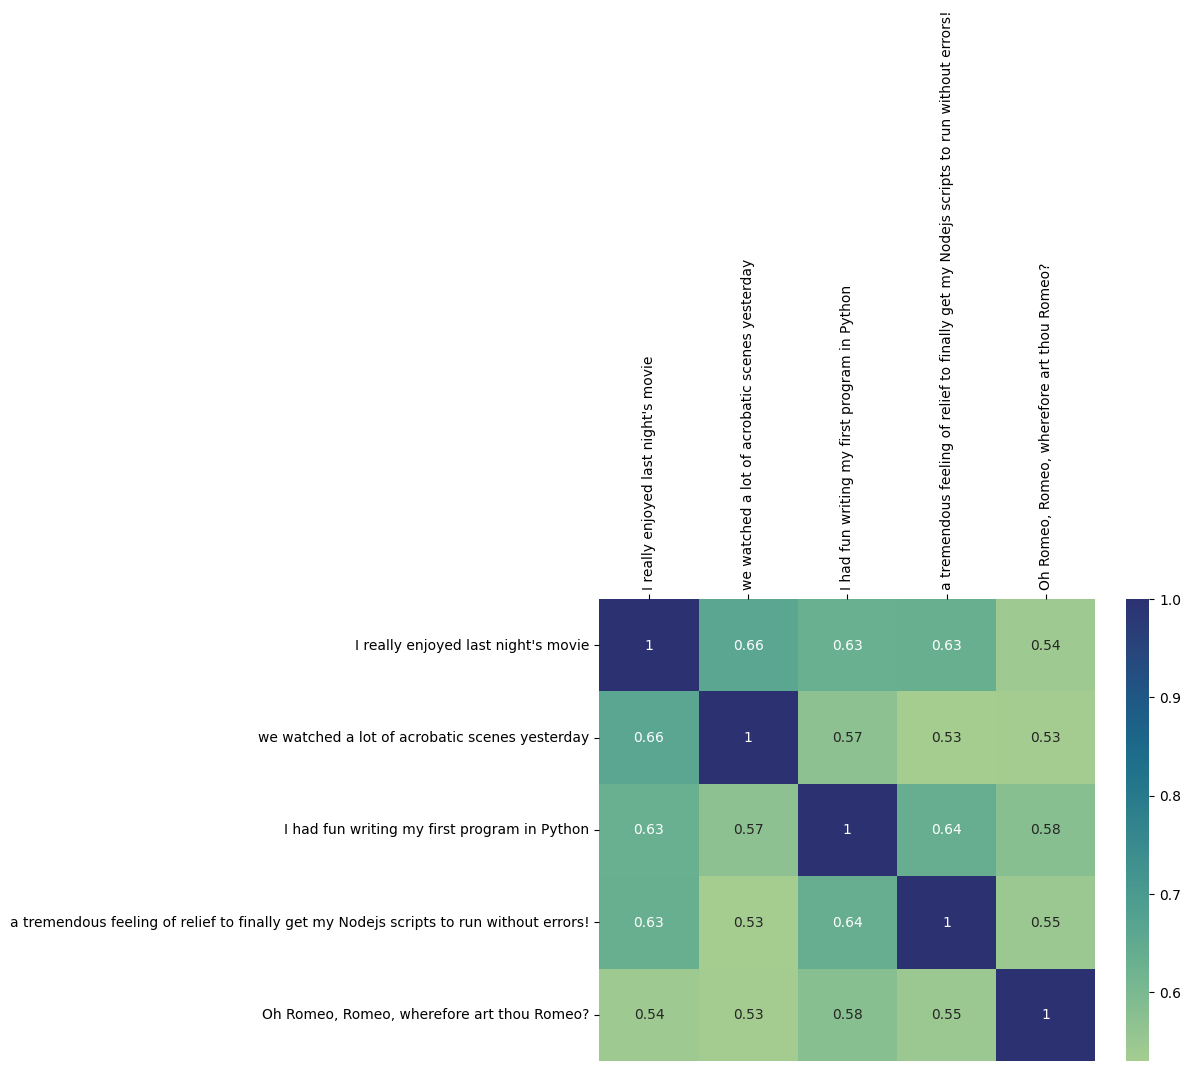

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ax = sns.heatmap(similarities, annot=True, cmap="crest")
ax.xaxis.tick_top()
ax.set_xticklabels(text, rotation=90)
plt.show()

## **Use Case**: Multimodal Document Similarity Analysis

Document similarity analysis leverages multimodal embedding models to map entire PDF files into a high-fidelity vector space. Unlike traditional keyword matching, these embeddings encapsulate the latent semantic meaning of the content.

By measuring the angular distance (Cosine Similarity) between these vectors, you can identify documents with conceptually related content, regardless of differences in formatting, language nuances, or visual layout.

In this walkthrough, you will:

- Extract and Truncate PDF content to comply with model constraints.
- Generate Embeddings for a corpus of documents using Gemini Embedding 2.
- Store and Query the vectors using a Pandas DataFrame to find the most relevant document matches.

**[IMPORTANT]**
⚠️ Page Limit Constraint: Currently, the model supports a maximum of 6 pages per PDF. If your document is longer, you must truncate the file before processing to avoid an INVALID_ARGUMENT error.

First, we will fetch the sample PDF reports required for this analysis.

In [92]:
!wget -O google-q3-2025-report.pdf https://s206.q4cdn.com/479360582/files/doc_financials/2025/q3/2025q3-alphabet-earnings-release.pdf  -q
!wget -O google-q4-2025-report.pdf https://s206.q4cdn.com/479360582/files/doc_financials/2025/q4/2025q4-alphabet-earnings-release.pdf -q
!wget -O meta-q4-2025-report.pdf https://s21.q4cdn.com/399680738/files/doc_financials/2025/q4/Earnings-Presentation-Q4-2025-FINAL.pdf -q
!wget -O gemini-2.5-report.pdf https://storage.googleapis.com/deepmind-media/gemini/gemini_v2_5_report.pdf -q

In [93]:
# Sending raw bytes


def truncate_pdf_bytes(file_path, max_pages=6):
    """Extracts the first N pages of a PDF and returns them as bytes."""
    doc = fitz.open(file_path)
    new_doc = fitz.open()

    pages_to_copy = min(max_pages, len(doc))
    new_doc.insert_pdf(doc, from_page=0, to_page=pages_to_copy - 1)

    pdf_buffer = io.BytesIO()
    new_doc.save(pdf_buffer)

    truncated_bytes = pdf_buffer.getvalue()

    new_doc.close()
    doc.close()

    return truncated_bytes


local_filename = "google-q3-2025-report.pdf"

pdf_bytes = truncate_pdf_bytes(local_filename, max_pages=6)

pdf_part = types.Part.from_bytes(
    data=pdf_bytes,
    mime_type="application/pdf",
)

response = client.models.embed_content(
    model=MODEL_ID,
    contents=[pdf_part],
)

print(f"Dimensions: {len(response.embeddings[0].values)}")
print(
    f"{response.embeddings[0].values[:5]} ... [{len(response.embeddings[0].values) - 5} more values]"
)
print()

Dimensions: 3072
[0.011847869, 0.0083854, -0.0030813955, -0.0057041817, 0.018917413] ... [3067 more values]



Now you will create a new dataframe column called `embeddings` to generate the embeddings for each text using the embedding model.

In [94]:
# Defining a dataframe for the docs


def pdfBytes(pdf):
    truncated_pdf_bytes = truncate_pdf_bytes(pdf, max_pages=6)
    pdf_part = types.Part.from_bytes(
        data=truncated_pdf_bytes, mime_type="application/pdf"
    )
    return pdf_part


import pandas as pd

title = [
    "Google Q3 2025 Report",
    "Google Q4 2025 Report",
    "Meta Q4 2025 Report",
    "Gemini 2.5 Tech Report",
]

document = [
    "google-q3-2025-report.pdf",
    "google-q4-2025-report.pdf",
    "meta-q4-2025-report.pdf",
    "gemini-2.5-report.pdf",
]

document_bytes = [
    [pdfBytes("google-q3-2025-report.pdf")],
    [pdfBytes("google-q4-2025-report.pdf")],
    [pdfBytes("meta-q4-2025-report.pdf")],
    [pdfBytes("gemini-2.5-report.pdf")],
]

df = pd.DataFrame(
    {"title": title, "document": document, "document_bytes": document_bytes}
)
df

,title,document,document_bytes
0,Google Q3 2025 Report,google-q3-2025-report.pdf,[media_resolution=None code_execution_result=N...
1,Google Q4 2025 Report,google-q4-2025-report.pdf,[media_resolution=None code_execution_result=N...
2,Meta Q4 2025 Report,meta-q4-2025-report.pdf,[media_resolution=None code_execution_result=N...
3,Gemini 2.5 Tech Report,gemini-2.5-report.pdf,[media_resolution=None code_execution_result=N...


In [95]:
# Embed the documents

df["embeddings"] = df.apply(
    lambda x: client.models.embed_content(
        model=MODEL_ID, contents=(x["document_bytes"])
    )
    .embeddings[0]
    .values,
    axis=1,
)
df

,title,document,document_bytes,embeddings
0,Google Q3 2025 Report,google-q3-2025-report.pdf,[media_resolution=None code_execution_result=N...,"[0.011847869, 0.0083854, -0.0030813955, -0.005..."
1,Google Q4 2025 Report,google-q4-2025-report.pdf,[media_resolution=None code_execution_result=N...,"[0.011847869, 0.0083854, -0.0030813955, -0.005..."
2,Meta Q4 2025 Report,meta-q4-2025-report.pdf,[media_resolution=None code_execution_result=N...,"[0.011847869, 0.0083854, -0.0030813955, -0.005..."
3,Gemini 2.5 Tech Report,gemini-2.5-report.pdf,[media_resolution=None code_execution_result=N...,"[0.011847869, 0.0083854, -0.0030813955, -0.005..."


### Analyze the similarity of PDF documents with cosine similarity

By converting PDF documents into embeddings, you can calculate similarity scores. There are many ways to calculate similarity scores, and a common technique is to use [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity).

In the example above, the PDF files in the collection cover different topics. The cosine similarity scores should be higher (close to 1.0) when making pairwise comparisons between documents on related subjects, and the scores should be lower between documents on unrelated topics.

The DataFrame output below shows the resulting cosine similarity scores between the document embeddings:

In [96]:
# Calculate similarities between docs

from sklearn.metrics.pairwise import cosine_similarity

cos_sim_array = cosine_similarity(list(df.embeddings.values))
similarities = pd.DataFrame(
    cos_sim_array,
    index=df.title,
    columns=df.title,
)
similarities

title,Google Q3 2025 Report,Google Q4 2025 Report,Meta Q4 2025 Report,Gemini 2.5 Tech Report
title,,,,
Google Q3 2025 Report,1.0,1.0,1.0,1.0
Google Q4 2025 Report,1.0,1.0,1.0,1.0
Meta Q4 2025 Report,1.0,1.0,1.0,1.0
Gemini 2.5 Tech Report,1.0,1.0,1.0,1.0


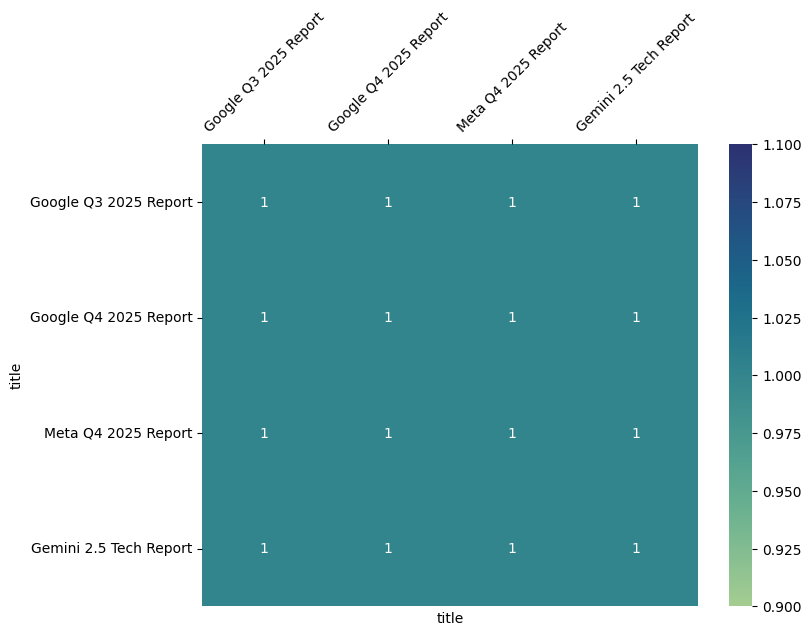

In [97]:
# confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ax = sns.heatmap(similarities, annot=True, cmap="crest")
ax.xaxis.tick_top()
ax.set_xticklabels(title, rotation=45)
plt.show()

## Using `task_type` for different scenarios

When generating embeddings, especially for complex systems like Retrieval Augmented Generation (RAG), a one-size-fits-all approach can sometimes lead to lower-quality results. For instance, a question like "Why is the sky blue?" and its answer, "The scattering of sunlight causes the blue color," have distinct meanings as statements, and a general-purpose embedding model might not recognize their strong relationship. To solve this, you can specify a `task_type` when creating embeddings. This instructs the model to produce vectors that are specifically optimized for your intended use case, which can significantly improve performance while also saving time and cost.

The Gemini embedding model supports several task types, each tailored for a specific goal. Here’s a general overview of the available types and their applications:

*   **`SEMANTIC_SIMILARITY`**: Use this when your goal is to assess how semantically similar two pieces of text are.
*   **`RETRIEVAL_QUERY`** and **`RETRIEVAL_DOCUMENT`**: These are essential for information retrieval tasks. Use `RETRIEVAL_QUERY` for the user's search query and `RETRIEVAL_DOCUMENT` for the texts in your database that you want to search through. This is the foundation for building effective semantic search and RAG systems.
*   **`CLASSIFICATION`**: Choose this task type when you intend to use the embeddings to train a model that classifies text into a set of predefined categories.
*   **`CLUSTERING`**: If your goal is to group similar texts together to identify hidden trends or topics without pre-existing labels, this task type will generate embeddings optimized for that purpose.

This example is an intuition of how more complex RAG systems work - like when you are building one FAQ system. You will:

- define some information, representing data from documents
- use the embedding model to generate the embeddings for those information
- look for information similar to the question asked
- then use a Gemini generative model to customize one answer to the question.

First you will declare the information representing the documents, create one structure including document titles and contents and create a dataframe from it.

In [98]:
contents01 = """
    Operating the Climate Control System Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car.
    To operate the climate control system, use the buttons and knobs located on the center console.
    Temperature: The temperature knob controls the temperature inside the car.
    Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature.
    Airflow: The airflow knob controls the amount of airflow inside the car.
    Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow.
    Fan speed: The fan speed knob controls the speed of the fan.
    Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed.
    Mode: The mode button allows you to select the desired mode.
    The available modes are: Auto: The car will automatically adjust the temperature and airflow to maintain a comfortable level.
    Cool: The car will blow cool air into the car.
    Heat: The car will blow warm air into the car.
    Defrost: The car will blow warm air onto the windshield to defrost it.
"""

contents02 = """
    Your Googlecar has a large touchscreen display that provides access to a variety of features, including navigation, entertainment, and climate control.
    To use the touchscreen display, simply touch the desired icon.
    For example, you can touch the "Navigation" icon to get directions to your destination or touch the "Music" icon to play your favorite songs.
"""

contents03 = """
    Shifting Gears Your Googlecar has an automatic transmission.
    To shift gears, simply move the shift lever to the desired position.
    Park: This position is used when you are parked. The wheels are locked and the car cannot move.
    Reverse: This position is used to back up.
    Neutral: This position is used when you are stopped at a light or in traffic.
    The car is not in gear and will not move unless you press the gas pedal.
    Drive: This position is used to drive forward.
    Low: This position is used for driving in snow or other slippery conditions.
"""

document01 = {
    "title": "Climate control system",
    "contents": " ".join(contents01.split()),
}
document02 = {"title": "Touchscreen", "contents": " ".join(contents02.split())}
document03 = {"title": "Shifting gears", "contents": " ".join(contents03.split())}

documents = [document01, document02, document03]

docs_df = pd.DataFrame(documents)
docs_df.columns = ["title", "contents"]
docs_df

,title,contents
0,Climate control system,Operating the Climate Control System Your Goog...
1,Touchscreen,Your Googlecar has a large touchscreen display...
2,Shifting gears,Shifting Gears Your Googlecar has an automatic...


Now you will create the embeddings using the (`RETRIEVAL_DOCUMENT` task type) column into the dataframe:

In [99]:
docs_df["embeddings"] = docs_df.apply(
    lambda x: client.models.embed_content(
        model=MODEL_ID,
        contents=(x["contents"]),
        config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT"),
    )
    .embeddings[0]
    .values,
    axis=1,
)
docs_df

,title,contents,embeddings
0,Climate control system,Operating the Climate Control System Your Goog...,"[0.016103351, 0.013950793, 0.005058919, 0.0033..."
1,Touchscreen,Your Googlecar has a large touchscreen display...,"[0.009598247, 0.02771081, -0.0031557423, 0.008..."
2,Shifting gears,Shifting Gears Your Googlecar has an automatic...,"[0.0027613419, -0.0029449023, -0.010233826, 4...."


Now you will create a function to do the interaction between questions and the search in the dataframe.

The `find_best_passage` function to, instead of searching for simple keywords, it searches for meaning.

Here’s a step-by-step breakdown of what it does when you ask a question:

- First, the function takes your query (e.g., "how do I change gears?") and uses the embedding model to convert it into an embedding using the `RETRIEVAL_QUERY` task type.
- Then the function compares the embeddings from your question to the numbers of every single document. It calculates a similarity score for each pair. A higher score means the meanings are more closely aligned.
- Finally, the function identifies the document with the single highest similarity score and returns its original text as the most relevant answer to your question

In [100]:
import numpy as np


def find_best_passage(query: str, dataframe: pd.DataFrame, model: str) -> str:

    # 1. Create an embedding for the user's query.
    query_embedding = client.models.embed_content(
        model=model,
        contents=query,
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY"),
    )

    # 2. Calculate the dot product to find the similarity between the query and all documents
    dot_products = np.dot(
        np.stack(dataframe.embeddings), query_embedding.embeddings[0].values
    )

    # 3. Find the index of the highest score and return the corresponding text.
    best_passage_index = np.argmax(dot_products)

    # 4. return the document contents more relevant to the question
    return dataframe.contents.iloc[best_passage_index]

Per example, for the question `"how to make the fan speed stronger on the car cooling system"` you have the following passage as the closest one:

In [101]:
question = "how to make the fan speed stronger on the car cooling system"

best_passage = find_best_passage(question, docs_df, MODEL_ID)
best_passage

'Operating the Climate Control System Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console. Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls the speed of the fan. Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed. Mode: The mode button allows you to select the desired mode. The available modes are: Auto: The car will automatically adjust the temperature and airflow to maintain a comfortable level. Cool: The car will blow cool air into the car. Heat: The car will blo

Now you can do one augmented generation (the last step of the RAG process) using the best passage found by the first step, but still having custom answers for users instead of simply pasting large documents chunks directly:

In [103]:
from IPython.display import Markdown

final_answer_prompt = f"""
    Your Role: You are a friendly AI assistant. Your purpose is to explain information to users who are not experts.

    Your Task: Use the provided "Source Text" below to answer the user's question.

    Guidelines for your Response:

    Be Clear and Simple: Explain any complicated ideas in easy-to-understand terms. Avoid jargon.
    Be Friendly: Write in a warm, conversational, and approachable tone.
    Be Thorough: Construct a complete and detailed answer in full sentences, using all the relevant information from the source text.
    Stay on Topic: If the source text does not contain the answer, you must state that the information is not available in the provided material. Do not use outside knowledge.

    QUESTION: {question}
    PASSAGE: {best_passage}
"""

ANOTHER_MODEL_ID = "gemini-3-flash-preview"  # @param ["gemini-2.5-flash-lite", "gemini-2.5-flash", "gemini-2.5-pro", "gemini-2.5-flash-preview", "gemini-3.1-flash-lite-preview", "gemini-3.1-pro-preview"] {"allow-input":true, isTemplate: true}

another_client = genai.Client(vertexai=True, project=PROJECT_ID, location="global")

final_answer = another_client.models.generate_content(
    model=ANOTHER_MODEL_ID,
    contents=final_answer_prompt,
)

Markdown(final_answer.text)

Hello! I'd be happy to help you with that.

To make the fan speed stronger in your Googlecar, you should use the controls located on the center console. Simply find the knob labeled **fan speed** and turn it **clockwise** (to the right). This will increase the speed of the fan.

If you want more air moving through the car in general, you can also turn the **airflow knob** clockwise, which will increase the total amount of airflow inside the vehicle.

I hope this helps you stay cool and comfortable!

## Next Steps

- Explore [multimodal embeddings tutorial](https://github.com/GoogleCloudPlatform/generative-ai/blob/main/embeddings/intro_multimodal_embeddings.ipynb).
- Check out the [Gemini Embedding 2 documentation](https://docs.cloud.google.com/vertex-ai/generative-ai/docs/models/gemini/embedding-2) for detailed model parameter references.